In [1]:
!pip install shap

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit

import shap

from catboost import CatBoostRegressor

In [3]:
from pathlib import Path

CWD = Path.cwd()
PROJECT_ROOT = CWD.parent.parent
PROCESSED_DIR = PROJECT_ROOT / "Data" / "Processed"

print(PROCESSED_DIR)

C:\Users\Sameen\10 Pearls Project\AQI Predictor\Data\Processed


In [4]:
df = pd.read_csv(PROCESSED_DIR / "Aqi_Data_Three_Day_Prediction_New.csv", index_col="time", parse_dates=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 26184 entries, 2023-08-04 00:00:00+05:00 to 2026-07-29 23:00:00+05:00
Data columns (total 50 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   temperature_2m             26184 non-null  float64
 1   wind_speed_10m             26184 non-null  float64
 2   relative_humidity_2m       26184 non-null  int64  
 3   surface_pressure           26184 non-null  float64
 4   boundary_layer_height      21816 non-null  float64
 5   dew_point_2m               26184 non-null  float64
 6   precipitation              26184 non-null  float64
 7   cloud_cover                26184 non-null  int64  
 8   wind_direction_10m         26184 non-null  int64  
 9   wind_gusts_10m             26184 non-null  float64
 10  shortwave_radiation        26184 non-null  float64
 11  pm10                       26184 non-null  float64
 12  pm2_5                      26184 non-null  float64
 13 

In [5]:
df.head()

,temperature_2m,wind_speed_10m,relative_humidity_2m,surface_pressure,boundary_layer_height,dew_point_2m,precipitation,cloud_cover,wind_direction_10m,wind_gusts_10m,...,f72_surface_pressure,f72_boundary_layer_height,f72_dew_point_2m,f72_precipitation,f72_cloud_cover,f72_wind_gusts_10m,f72_shortwave_radiation,wind_pollution_dispersion,pressure_change_3hour,Humidity_Level
time,,,,,,,,,,,,,,,,,,,,,
2023-08-04 00:00:00+05:00,27.4,18.7,90,1000.1,785.0,25.5,0.0,24,251,26.6,...,1000.6,860.0,24.7,0.0,99.0,44.3,0.0,14679.5,0.2,1.9
2023-08-04 01:00:00+05:00,27.2,19.0,90,999.3,810.0,25.5,0.0,23,255,27.0,...,1000.0,880.0,24.9,0.0,93.0,44.3,0.0,15390.0,-0.9,1.7
2023-08-04 02:00:00+05:00,27.0,17.7,92,998.6,790.0,25.5,0.0,19,257,27.4,...,999.3,870.0,24.9,0.0,44.0,44.3,0.0,13983.0,-1.7,1.5
2023-08-04 03:00:00+05:00,26.9,17.1,92,998.7,845.0,25.5,0.0,49,255,25.2,...,999.0,870.0,24.8,0.0,45.0,43.9,0.0,14449.5,-1.4,1.4
2023-08-04 04:00:00+05:00,27.0,20.0,92,998.8,830.0,25.5,0.0,33,262,28.4,...,998.9,860.0,24.9,0.0,19.0,43.2,0.0,16600.0,-0.5,1.5


# Train And Test Split

In [6]:
df.columns

Index(['temperature_2m', 'wind_speed_10m', 'relative_humidity_2m',
       'surface_pressure', 'boundary_layer_height', 'dew_point_2m',
       'precipitation', 'cloud_cover', 'wind_direction_10m', 'wind_gusts_10m',
       'shortwave_radiation', 'pm10', 'pm2_5', 'carbon_monoxide',
       'nitrogen_dioxide', 'sulphur_dioxide', 'ozone', 'dust',
       'aerosol_optical_depth', 'us_aqi', 'hour', 'day', 'month', 'dayofweek',
       'quarter', 'previous_hour_aqi', 'previous_day_aqi', 'aqi_change_rate',
       'rolled_mean_aqi_6hr', 'rolled_mean_aqi_24hr', 'rolled_mean_aqi_72hr',
       'rolled_std_aqi_6hr', 'rolled_std_aqi_24hr', 'rolled_std_aqi_72hr',
       'ewm_aqi_24hr', 'ewm_std_24hr', 'Day_3_Future_AQI',
       'f72_temperature_2m', 'f72_wind_speed_10m', 'f72_relative_humidity_2m',
       'f72_surface_pressure', 'f72_boundary_layer_height', 'f72_dew_point_2m',
       'f72_precipitation', 'f72_cloud_cover', 'f72_wind_gusts_10m',
       'f72_shortwave_radiation', 'wind_pollution_dispersion

In [7]:
X = df.drop(columns = ['Day_3_Future_AQI'])
Y = df['Day_3_Future_AQI']

In [8]:
X

,temperature_2m,wind_speed_10m,relative_humidity_2m,surface_pressure,boundary_layer_height,dew_point_2m,precipitation,cloud_cover,wind_direction_10m,wind_gusts_10m,...,f72_surface_pressure,f72_boundary_layer_height,f72_dew_point_2m,f72_precipitation,f72_cloud_cover,f72_wind_gusts_10m,f72_shortwave_radiation,wind_pollution_dispersion,pressure_change_3hour,Humidity_Level
time,,,,,,,,,,,,,,,,,,,,,
2023-08-04 00:00:00+05:00,27.4,18.7,90,1000.1,785.0,25.5,0.0,24,251,26.6,...,1000.6,860.0,24.7,0.0,99.0,44.3,0.0,14679.5,0.2,1.9
2023-08-04 01:00:00+05:00,27.2,19.0,90,999.3,810.0,25.5,0.0,23,255,27.0,...,1000.0,880.0,24.9,0.0,93.0,44.3,0.0,15390.0,-0.9,1.7
2023-08-04 02:00:00+05:00,27.0,17.7,92,998.6,790.0,25.5,0.0,19,257,27.4,...,999.3,870.0,24.9,0.0,44.0,44.3,0.0,13983.0,-1.7,1.5
2023-08-04 03:00:00+05:00,26.9,17.1,92,998.7,845.0,25.5,0.0,49,255,25.2,...,999.0,870.0,24.8,0.0,45.0,43.9,0.0,14449.5,-1.4,1.4
2023-08-04 04:00:00+05:00,27.0,20.0,92,998.8,830.0,25.5,0.0,33,262,28.4,...,998.9,860.0,24.9,0.0,19.0,43.2,0.0,16600.0,-0.5,1.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-07-29 19:00:00+05:00,28.9,14.1,83,997.2,540.0,25.7,0.0,6,224,36.4,...,997.3,545.0,25.3,0.0,98.0,35.6,42.0,7614.0,0.4,3.2
2026-07-29 20:00:00+05:00,28.4,11.6,85,997.8,485.0,25.7,0.0,14,231,34.6,...,997.9,530.0,25.2,0.0,99.0,30.2,1.0,5626.0,0.8,2.7
2026-07-29 21:00:00+05:00,28.6,10.7,84,998.8,500.0,25.5,0.0,22,240,28.8,...,998.4,490.0,25.2,0.0,100.0,29.9,0.0,5350.0,1.7,3.1


In [9]:
Y

time
2023-08-04 00:00:00+05:00    77.0
2023-08-04 01:00:00+05:00    77.0
2023-08-04 02:00:00+05:00    77.0
2023-08-04 03:00:00+05:00    77.0
2023-08-04 04:00:00+05:00    77.0
                             ... 
2026-07-29 19:00:00+05:00    89.0
2026-07-29 20:00:00+05:00    88.0
2026-07-29 21:00:00+05:00    88.0
2026-07-29 22:00:00+05:00    88.0
2026-07-29 23:00:00+05:00    88.0
Name: Day_3_Future_AQI, Length: 26184, dtype: float64

In [10]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, shuffle = False)

In [11]:
len(X_train)

20947

In [12]:
len(X_test)

5237

# Building CatBoost Model For Day Three

In [13]:
cbr = CatBoostRegressor(iterations = 100,
                        depth = 6,
                        random_state = 42,
                        learning_rate = 0.02,
                        l2_leaf_reg = 6,
                        loss_function = 'RMSE')

In [14]:
cbr.fit(X_train, Y_train)

0:	learn: 24.0767823	total: 145ms	remaining: 14.4s
1:	learn: 23.8861590	total: 175ms	remaining: 8.6s
2:	learn: 23.6962448	total: 219ms	remaining: 7.07s
3:	learn: 23.5101975	total: 264ms	remaining: 6.34s
4:	learn: 23.3405992	total: 308ms	remaining: 5.85s
5:	learn: 23.1685678	total: 358ms	remaining: 5.62s
6:	learn: 22.9998542	total: 395ms	remaining: 5.25s
7:	learn: 22.8354529	total: 435ms	remaining: 5s
8:	learn: 22.6825400	total: 473ms	remaining: 4.79s
9:	learn: 22.5247817	total: 528ms	remaining: 4.75s
10:	learn: 22.3825709	total: 577ms	remaining: 4.67s
11:	learn: 22.2420929	total: 615ms	remaining: 4.51s
12:	learn: 22.0951369	total: 648ms	remaining: 4.34s
13:	learn: 21.9599677	total: 688ms	remaining: 4.23s
14:	learn: 21.8335033	total: 731ms	remaining: 4.14s
15:	learn: 21.7001892	total: 770ms	remaining: 4.04s
16:	learn: 21.5740063	total: 814ms	remaining: 3.97s
17:	learn: 21.4509101	total: 868ms	remaining: 3.95s
18:	learn: 21.3290411	total: 895ms	remaining: 3.81s
19:	learn: 21.2119582	tota

CatBoostRegressor(depth=6, iterations=100, l2_leaf_reg=6, learning_rate=0.02, loss_function='RMSE', random_state=42)

In [15]:
y_pred = cbr.predict(X_test)

# Evaluating the Model

In [16]:
R2_Score = r2_score(Y_test, y_pred)
Mae = mean_absolute_error(Y_test, y_pred)
Mean_Square_Error = mean_squared_error(Y_test, y_pred)
Root_Mean_Square_Error = np.sqrt(Mean_Square_Error)

print("Evaluation Metrics: ")
print(f"R2 Score: {R2_Score}")
print(f"Mean Absolute Error: {Mae}")
print(f"Mean Square Error: {Mean_Square_Error}")
print(f"Root Mean Square Error: {Root_Mean_Square_Error}")

Evaluation Metrics: 
R2 Score: 0.3310486140951454
Mean Absolute Error: 11.869540034387347
Mean Square Error: 268.8385269359991
Root Mean Square Error: 16.39629613467624


# Note:
- Not much Improvement will come even if I do hyper parameter optimization. I will try other method

# Now Day Wise

In [17]:
day3 = pd.read_csv(PROCESSED_DIR / "Cyclic_Day_Three_AQI.csv", index_col="time", parse_dates=True)
day3.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1088 entries, 2023-08-04 00:00:00+05:00 to 2026-07-26 00:00:00+05:00
Data columns (total 52 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   temperature_2m               1088 non-null   float64
 1   wind_speed_10m               1088 non-null   float64
 2   relative_humidity_2m         1088 non-null   float64
 3   surface_pressure             1088 non-null   float64
 4   boundary_layer_height        907 non-null    float64
 5   dew_point_2m                 1088 non-null   float64
 6   precipitation                1088 non-null   float64
 7   cloud_cover                  1088 non-null   float64
 8   wind_direction_10m           1088 non-null   float64
 9   wind_gusts_10m               1088 non-null   float64
 10  shortwave_radiation          1088 non-null   float64
 11  pm10                         1088 non-null   float64
 12  pm2_5                       

In [18]:
day3.head()

,temperature_2m,wind_speed_10m,relative_humidity_2m,surface_pressure,boundary_layer_height,dew_point_2m,precipitation,cloud_cover,wind_direction_10m,wind_gusts_10m,...,Day_3_Future_AQI,cyclic_day_sin,cyclic_day_cos,cyclic_week_sin,cyclic_week_cos,delta_temperature_2m,delta_wind_speed_10m,delta_surface_pressure,delta_relative_humidity_2m,delta_boundary_layer_height
time,,,,,,,,,,,,,,,,,,,,,
2023-08-04 00:00:00+05:00,28.441667,20.516667,83.458333,1000.087500,752.708333,25.291667,0.037500,50.083333,245.083333,31.941667,...,78.875000,-0.545240,-0.838280,-0.433884,-0.900969,-0.400000,12.704167,-1.095833,-3.250000,163.750000
2023-08-05 00:00:00+05:00,28.329167,21.941667,81.750000,1002.600000,818.333333,24.866667,0.037500,69.833333,247.750000,33.450000,...,78.791667,-0.559589,-0.828770,-0.974928,-0.222521,-0.333333,7.487500,-3.237500,-0.083333,-12.916667
2023-08-06 00:00:00+05:00,28.233333,30.679167,80.375000,1001.608333,900.416667,24.479167,0.029167,81.625000,254.500000,45.562500,...,73.416667,-0.573772,-0.819015,-0.781831,0.623490,-0.262500,-2.241667,0.979167,1.250000,-101.666667
2023-08-07 00:00:00+05:00,28.041667,33.220833,80.208333,998.991667,916.458333,24.266667,0.070833,75.000000,250.250000,49.770833,...,68.791667,-0.587785,-0.809017,0.000000,1.000000,-0.212500,-5.650000,4.616667,2.250000,-140.416667
2023-08-08 00:00:00+05:00,27.995833,29.429167,81.666667,999.362500,805.416667,24.512500,0.091667,68.541667,245.916667,44.275000,...,69.916667,-0.601624,-0.798779,0.781831,0.623490,-0.275000,-3.066667,4.620833,0.625000,-81.250000


# Train And Test Split

In [19]:
day3.columns

Index(['temperature_2m', 'wind_speed_10m', 'relative_humidity_2m',
       'surface_pressure', 'boundary_layer_height', 'dew_point_2m',
       'precipitation', 'cloud_cover', 'wind_direction_10m', 'wind_gusts_10m',
       'shortwave_radiation', 'pm10', 'pm2_5', 'carbon_monoxide',
       'nitrogen_dioxide', 'sulphur_dioxide', 'ozone', 'dust',
       'aerosol_optical_depth', 'us_aqi', 'month', 'dayofweek',
       'previous_day_aqi', 'rolled_mean_aqi_24hr', 'rolled_mean_aqi_72hr',
       'rolled_std_aqi_24hr', 'rolled_std_aqi_72hr', 'ewm_aqi_24hr',
       'ewm_std_24hr', 'f72_temperature_2m', 'f72_wind_speed_10m',
       'f72_relative_humidity_2m', 'f72_surface_pressure',
       'f72_boundary_layer_height', 'f72_dew_point_2m', 'f72_precipitation',
       'f72_cloud_cover', 'f72_wind_gusts_10m', 'f72_shortwave_radiation',
       'wind_pollution_dispersion', 'pressure_change_3hour', 'Humidity_Level',
       'Day_3_Future_AQI', 'cyclic_day_sin', 'cyclic_day_cos',
       'cyclic_week_sin', 'cy

In [20]:
X1 = day3.drop(columns = ['Day_3_Future_AQI'])
Y1 = day3['Day_3_Future_AQI']

In [21]:
X1

,temperature_2m,wind_speed_10m,relative_humidity_2m,surface_pressure,boundary_layer_height,dew_point_2m,precipitation,cloud_cover,wind_direction_10m,wind_gusts_10m,...,Humidity_Level,cyclic_day_sin,cyclic_day_cos,cyclic_week_sin,cyclic_week_cos,delta_temperature_2m,delta_wind_speed_10m,delta_surface_pressure,delta_relative_humidity_2m,delta_boundary_layer_height
time,,,,,,,,,,,,,,,,,,,,,
2023-08-04 00:00:00+05:00,28.441667,20.516667,83.458333,1000.087500,752.708333,25.291667,0.037500,50.083333,245.083333,31.941667,...,3.150000,-0.545240,-0.838280,-0.433884,-0.900969,-0.400000,12.704167,-1.095833,-3.250000,163.750000
2023-08-05 00:00:00+05:00,28.329167,21.941667,81.750000,1002.600000,818.333333,24.866667,0.037500,69.833333,247.750000,33.450000,...,3.462500,-0.559589,-0.828770,-0.974928,-0.222521,-0.333333,7.487500,-3.237500,-0.083333,-12.916667
2023-08-06 00:00:00+05:00,28.233333,30.679167,80.375000,1001.608333,900.416667,24.479167,0.029167,81.625000,254.500000,45.562500,...,3.754167,-0.573772,-0.819015,-0.781831,0.623490,-0.262500,-2.241667,0.979167,1.250000,-101.666667
2023-08-07 00:00:00+05:00,28.041667,33.220833,80.208333,998.991667,916.458333,24.266667,0.070833,75.000000,250.250000,49.770833,...,3.775000,-0.587785,-0.809017,0.000000,1.000000,-0.212500,-5.650000,4.616667,2.250000,-140.416667
2023-08-08 00:00:00+05:00,27.995833,29.429167,81.666667,999.362500,805.416667,24.512500,0.091667,68.541667,245.916667,44.275000,...,3.483333,-0.601624,-0.798779,0.781831,0.623490,-0.275000,-3.066667,4.620833,0.625000,-81.250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-07-22 00:00:00+05:00,29.454167,10.129167,78.833333,998.508333,585.833333,25.329167,0.020833,57.250000,218.375000,27.358333,...,4.125000,-0.345612,-0.938377,0.974928,-0.222521,0.087500,0.458333,1.125000,-2.333333,-2.083333
2026-07-23 00:00:00+05:00,29.962500,9.200000,75.791667,997.450000,491.875000,25.112500,0.016667,47.000000,206.333333,27.112500,...,4.850000,-0.361714,-0.932289,0.433884,-0.900969,-0.275000,1.266667,3.404167,-2.791667,107.083333
2026-07-24 00:00:00+05:00,30.233333,9.304167,76.625000,997.970833,503.958333,25.545833,0.000000,77.375000,233.250000,26.816667,...,4.687500,-0.377708,-0.925925,-0.433884,-0.900969,-0.404167,4.958333,1.891667,-3.500000,266.250000


In [22]:
Y1

time
2023-08-04 00:00:00+05:00    78.875000
2023-08-05 00:00:00+05:00    78.791667
2023-08-06 00:00:00+05:00    73.416667
2023-08-07 00:00:00+05:00    68.791667
2023-08-08 00:00:00+05:00    69.916667
                               ...    
2026-07-22 00:00:00+05:00    84.958333
2026-07-23 00:00:00+05:00    82.041667
2026-07-24 00:00:00+05:00    83.250000
2026-07-25 00:00:00+05:00    78.708333
2026-07-26 00:00:00+05:00    79.125000
Name: Day_3_Future_AQI, Length: 1088, dtype: float64

In [23]:
X_train1, X_test1, Y_train1, Y_test1 = train_test_split(X1, Y1, test_size=0.2, shuffle = False)

In [24]:
len(X_train1)

870

In [25]:
len(X_test1)

218

# Building CatBoost Model For Day Three

In [40]:
cbr1 = CatBoostRegressor(iterations = 900,
                        depth = 6,
                        random_seed = 42,
                        learning_rate = 0.02,
                        l2_leaf_reg = 6,
                        loss_function = 'RMSE')

cbr1.fit(X_train1, Y_train1)
y_pred1 = cbr1.predict(X_test1)

0:	learn: 22.9313714	total: 172ms	remaining: 2m 35s
1:	learn: 22.7744565	total: 290ms	remaining: 2m 10s
2:	learn: 22.6113363	total: 415ms	remaining: 2m 4s
3:	learn: 22.4490354	total: 525ms	remaining: 1m 57s
4:	learn: 22.2854416	total: 655ms	remaining: 1m 57s
5:	learn: 22.1379198	total: 775ms	remaining: 1m 55s
6:	learn: 21.9888436	total: 918ms	remaining: 1m 57s
7:	learn: 21.8426982	total: 1.06s	remaining: 1m 58s
8:	learn: 21.7146584	total: 1.19s	remaining: 1m 57s
9:	learn: 21.5771894	total: 1.29s	remaining: 1m 54s
10:	learn: 21.4286855	total: 1.42s	remaining: 1m 54s
11:	learn: 21.2794486	total: 1.54s	remaining: 1m 53s
12:	learn: 21.1403206	total: 1.64s	remaining: 1m 52s
13:	learn: 20.9868693	total: 1.74s	remaining: 1m 49s
14:	learn: 20.8784016	total: 1.86s	remaining: 1m 50s
15:	learn: 20.7505207	total: 1.98s	remaining: 1m 49s
16:	learn: 20.6204758	total: 2.08s	remaining: 1m 48s
17:	learn: 20.5116555	total: 2.18s	remaining: 1m 46s
18:	learn: 20.3966207	total: 2.27s	remaining: 1m 45s
19:	

# Evaluating the Model

In [41]:
R2_Score1 = r2_score(Y_test1, y_pred1)
Mae1 = mean_absolute_error(Y_test1, y_pred1)
Mean_Square_Error1 = mean_squared_error(Y_test1, y_pred1)
Root_Mean_Square_Error1 = np.sqrt(Mean_Square_Error1)

print("Evaluation Metrics: ")
print(f"R2 Score: {R2_Score1}")
print(f"Mean Absolute Error: {Mae1}")
print(f"Mean Square Error: {Mean_Square_Error1}")
print(f"Root Mean Square Error: {Root_Mean_Square_Error1}")

Evaluation Metrics: 
R2 Score: 0.5042536901396137
Mean Absolute Error: 9.866119401645946
Mean Square Error: 179.10752455253322
Root Mean Square Error: 13.383105938179419


# Baseline Prediction For Day Three

In [42]:
y_pred_baseline = X_test1['us_aqi']
R2_Score_baseline = r2_score(Y_test1, y_pred_baseline)

In [43]:
R2_Score_baseline

-0.08064124116268756

### So the Gain

In [44]:
R2_Score1 - R2_Score_baseline

0.5848949313023013

# Hyper Parameter Optimization Random Search 

In [45]:
random_grid = {
    "iterations": [200, 300, 500, 700, 900, 1200, 1500],
    "learning_rate": [0.005, 0.007, 0.01, 0.015, 0.02, 0.03, 0.05, 0.07, 0.1],
    "depth": [3, 4, 5, 6, 7],
    "l2_leaf_reg": [1, 2, 3, 5, 7, 10, 15, 20, 30],
    "random_strength": [0, 0.1, 0.2, 0.5, 1, 2, 3, 5],
    "bagging_temperature": [0, 0.1, 0.25, 0.5, 0.75, 1, 2, 3],
    "border_count": [32, 64, 128, 254],
}

In [46]:
ts = TimeSeriesSplit(n_splits = 5, test_size = 90)

cat_random = RandomizedSearchCV(estimator = CatBoostRegressor(loss_function='RMSE', random_seed =42),
                               param_distributions = random_grid,
                               n_iter = 100, 
                               cv = ts, 
                               random_state = 42,
                               n_jobs=-1)

cat_random.fit(X_train1, Y_train1)

0:	learn: 22.7283429	total: 12.6ms	remaining: 2.51s
1:	learn: 22.2984564	total: 29.7ms	remaining: 2.94s
2:	learn: 21.9501122	total: 41.3ms	remaining: 2.71s
3:	learn: 21.5996899	total: 53.9ms	remaining: 2.64s
4:	learn: 21.2792052	total: 66.3ms	remaining: 2.58s
5:	learn: 20.9800802	total: 78.8ms	remaining: 2.55s
6:	learn: 20.6659888	total: 90.3ms	remaining: 2.49s
7:	learn: 20.3657470	total: 106ms	remaining: 2.54s
8:	learn: 20.0814252	total: 120ms	remaining: 2.54s
9:	learn: 19.8249240	total: 135ms	remaining: 2.56s
10:	learn: 19.5839267	total: 145ms	remaining: 2.49s
11:	learn: 19.3449228	total: 157ms	remaining: 2.46s
12:	learn: 19.0966086	total: 169ms	remaining: 2.42s
13:	learn: 18.8898314	total: 179ms	remaining: 2.38s
14:	learn: 18.6980052	total: 190ms	remaining: 2.35s
15:	learn: 18.4765726	total: 201ms	remaining: 2.31s
16:	learn: 18.3006177	total: 216ms	remaining: 2.32s
17:	learn: 18.1632835	total: 233ms	remaining: 2.36s
18:	learn: 18.0122158	total: 249ms	remaining: 2.37s
19:	learn: 17.8

,estimator,CatBoostRegre...andom_seed=42)
,param_distributions,"{'bagging_temperature': [0, 0.1, ...], 'border_count': [32, 64, ...], 'depth': [3, 4, ...], 'iterations': [200, 300, ...], ...}"
,n_iter,100
,scoring,None
,n_jobs,-1
,refit,True
,cv,TimeSeriesSpl... test_size=90)
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [47]:
def evaluate(model, test_features, test_labels):
  predictions = model.predict(test_features)
  r2 = r2_score(test_labels, predictions)
  mae1 = mean_absolute_error(test_labels, predictions)
  mse1 = mean_squared_error(test_labels, predictions)
  rmse1 = np.sqrt(mse1)
  print('Model Performance')
  print(f"R2 Score Fine Tuned Model: {r2}")
  print(f"Mean Absolute Error: {mae1}")
  print(f"Mean Square Error: {mse1}")
  print(f"Root Mean Square Error: {rmse1}")
  return r2

In [48]:
best_random = cat_random.best_estimator_
print(best_random)

CatBoostRegressor(bagging_temperature=0.25, border_count=254, depth=5, iterations=200, l2_leaf_reg=30, learning_rate=0.05, loss_function='RMSE', random_seed=42, random_strength=0.2)


In [49]:
random_accuracy = evaluate(best_random,X_test1,Y_test1)

Model Performance
R2 Score Fine Tuned Model: 0.4814237923285838
Mean Absolute Error: 10.115745192378586
Mean Square Error: 187.35570795075643
Root Mean Square Error: 13.687794122894909


# SHAP STEP

### GET SHAP VALUES

In [50]:
explainer = shap.Explainer(best_random)
shap_values = explainer(X_test1)

### Waterfall Model

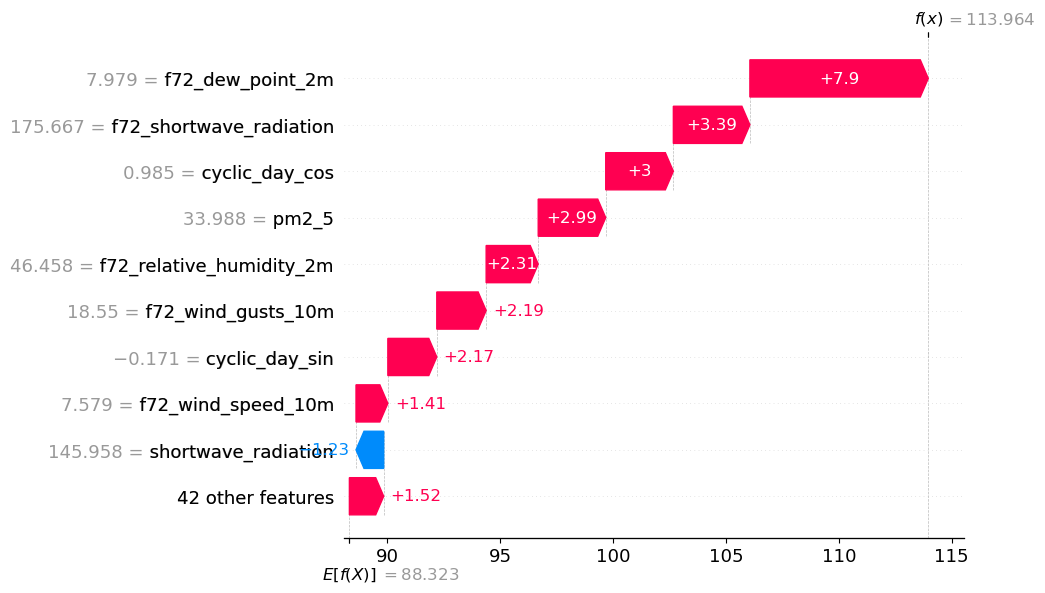

In [51]:
shap.plots.waterfall(shap_values[0])

### Beeswarm Plot

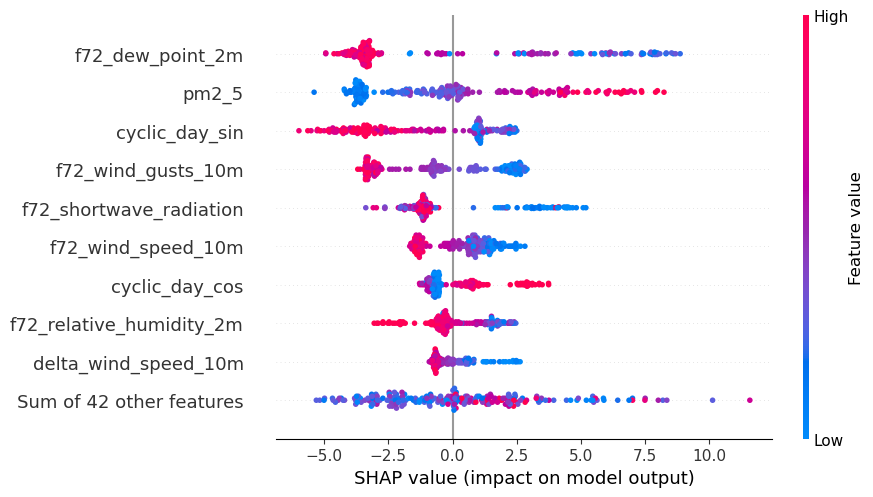

In [52]:
shap.plots.beeswarm(shap_values)

# Prediction Chart

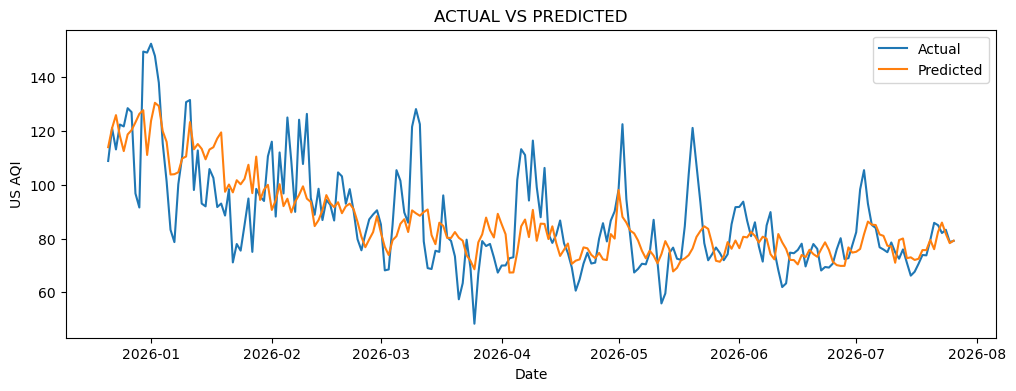

In [53]:
plt.figure(figsize=(12,4))
y_pred_tuned = best_random.predict(X_test1)
plt.plot(Y_test1.index, Y_test1.values, label="Actual")
plt.plot(Y_test1.index, y_pred_tuned, label="Predicted")
plt.legend(loc = "best")
plt.title("ACTUAL VS PREDICTED")
plt.ylabel("US AQI")
plt.xlabel("Date")
plt.show()